In [1]:
# Load HDFS log file and count lines
log_file = 'resource/HDFS_2k.log'

# Count total lines
with open(log_file, 'r') as f:
    total_lines = sum(1 for _ in f)

print(f"Total lines in {log_file}: {total_lines:,}")

Total lines in resource/HDFS_2k.log: 2,000


In [5]:
!pip install drain3

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Using legacy 'setup.py install' for drain3, since package 'wheel' is not installed.
  Attempting uninstall: cachetools
    Found existing installation: cachetools 6.2.6
    Uninstalling cachetools-6.2.6:
      Successfully uninstalled cachetools-6.2.6
  Running setup.py install for drain3: started
  Running setup.py install for drain3: finished with status 'done'


You should consider upgrading via the 'C:\Users\ACER\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


In [9]:
# Parse toàn bộ HDFS_2k.log với Drain3
log_file = 'resource/HDFS_2k.log'

# Load và parse log file
with open(log_file, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            miner.add_log_message(line)

templates_data = []
for cluster in miner.drain.clusters:
    templates_data.append({
        'template_id': cluster.cluster_id,
        'count': cluster.size,
        'template': cluster.get_template()
    })

# Sort by count descending
templates_data.sort(key=lambda x: x['count'], reverse=True)

# Display all templates
print(f"=== All Templates ({len(templates_data)} templates) ===\n")
for i, item in enumerate(templates_data, 1):
    print(f"{i}. [Template {item['template_id']}] count={item['count']:,}")
    print(f"   {item['template']}")
    print()

=== All Templates (20 templates) ===

1. [Template 5] count=628
   <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>

2. [Template 4] count=622
   <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating

3. [Template 6] count=584
   <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>

4. [Template 7] count=584
   <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>

5. [Template 10] count=526
   <*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>

6. [Template 13] count=448
   <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>

7. [Template 8] count=230
   <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>

8. [Template 11] count=160
   <*> <*> <*> INFO dfs.DataNode$DataXceiver: <*> Served block <*> to <*>

9. [Template 12] count=160
   <*> <*> <

In [69]:
# Export top-10 templates to CSV
import csv
import os

# Get top-10
top_10 = templates_data[:10]

# Create results directory
os.makedirs('results', exist_ok=True)

# Export to CSV
output_file = 'results/top_templates.csv'
with open(output_file, 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['template_id', 'template', 'count'])
    for item in top_10:
        writer.writerow([item['template_id'], item['template'], item['count']])

print(f"Exported top-10 templates to {output_file}\n")
print("Top-10 Templates:")
for i, item in enumerate(top_10, 1):
    print(f"{i:2d}. ID={item['template_id']:3d} | count={item['count']:6,d} | {item['template']}")

Exported top-10 templates to results/top_templates.csv

Top-10 Templates:
 1. ID=  1 | count=     3 | Connection timeout to <*> at <*> after <*>
 2. ID=  2 | count=     1 | Token validated for userId=USR-442918 in 12ms
 3. ID=  3 | count=     1 | Request completed /api/payment status=500 duration=30125ms
 4. ID=  4 | count=   622 | <*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
 5. ID=  5 | count=   628 | <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
 6. ID=  6 | count=   584 | <*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>
 7. ID=  7 | count=   584 | <*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>
 8. ID=  8 | count=   230 | <*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.allocateBlock: <*> <*>
 9. ID=  9 | count=    40 | <*> <*> 13 INFO dfs.DataBlockScanner: Verification succeeded for <*>
10.

In [12]:
# Tune drain_sim_th parameter: test 0.3, 0.5, 0.7
import pandas as pd

drain_sim_th_values = [0.3, 0.5, 0.7]
results = []

print("=== Tuning drain_sim_th ===\n")

for sim_th in drain_sim_th_values:
    print(f"Testing drain_sim_th = {sim_th}...")
    
    # Create new miner with different threshold
    test_config = TemplateMinerConfig()
    test_config.drain_sim_th = sim_th
    test_config.drain_depth = 4
    
    test_miner = TemplateMiner(config=test_config)
    
    # Parse log file
    with open(log_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line:
                test_miner.add_log_message(line)
    
    # Count templates
    num_templates = len(test_miner.drain.clusters)
    total_msgs = sum(cluster.size for cluster in test_miner.drain.clusters)
    
    results.append({
        'drain_sim_th': sim_th,
        'num_templates': num_templates,
        'total_messages': total_msgs,
        'avg_msgs_per_template': total_msgs / num_templates if num_templates > 0 else 0
    })
    
    print(f"  ✓ Templates: {num_templates}, Total messages: {total_msgs:,}")


=== Tuning drain_sim_th ===

Testing drain_sim_th = 0.3...
  ✓ Templates: 17, Total messages: 2,000
Testing drain_sim_th = 0.5...
  ✓ Templates: 21, Total messages: 2,000
Testing drain_sim_th = 0.7...
  ✓ Templates: 820, Total messages: 2,000


Phase 2

In [23]:
import pandas as pd
from collections import Counter

def create_template_timeseries(log_entries, window='5min'):
    """
    Biến parsed log thành time series per template.
    
    Args:
        log_entries: list of (timestamp, template_id) tuples
        window: aggregation window
    
    Returns:
        DataFrame: columns = template IDs, rows = time windows, values = count
    """
    df = pd.DataFrame(log_entries, columns=['timestamp', 'template_id'])
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Group by time window + template → count
    ts = df.groupby([pd.Grouper(key='timestamp', freq=window), 'template_id']).size()
    ts = ts.unstack(fill_value=0)  # pivot: rows=time, cols=template
    return ts


In [32]:
from datetime import datetime

log_entries = []

# Khởi tạo miner
best_config = TemplateMinerConfig()
best_config.drain_sim_th = 0.5
best_config.drain_depth = 4
best_miner = TemplateMiner(config=best_config)

# Parse log file
with open(log_file, 'r') as f:
    for idx, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        
        # 1. SỬA REGEX: Bắt cụm 6 số (ngày) + khoảng trắng + 6 số (giờ) ở đầu dòng
        timestamp_match = re.match(r'^(\d{6})\s+(\d{6})', line)
        
        if timestamp_match:
            date_part = timestamp_match.group(1) # '081109'
            time_part = timestamp_match.group(2) # '203615'
            
            # Chuyển định dạng '081109 203615' thành chuẩn '2008-11-09 20:36:15'
            try:
                dt = datetime.strptime(f"{date_part} {time_part}", "%y%m%d %H%M%S")
                timestamp_str = dt.strftime("%Y-%m-%d %H:%M:%S")
            except ValueError:
                timestamp_str = '2008-11-09 00:00:00'
        else:
            timestamp_str = '2008-11-09 00:00:00'
        
        # Parse với Drain3
        result = best_miner.add_log_message(line)
        template_id = result['cluster_id']
        
        log_entries.append((timestamp_str, template_id))

# 2. GỌI HÀM: Tạo bảng Time Series (Gom cụm mỗi 5 phút thành 1 dòng)
ts = create_template_timeseries(log_entries, window='5min')

# --- Giờ bạn có thể chạy đoạn code Print phía dưới của bạn một cách mượt mà rồi ---
print("=== Template Count Time Series ===\n")
header = "#"
for col in ts.columns:
    header += f" T-{col:03d}".rjust(6)
print(header)

for timestamp, row in ts.iterrows():
    line = f"# {str(timestamp)}"
    for val in row:
        line += f" {int(val):6d}"
    print(line)

=== Template Count Time Series ===

# T-001 T-002 T-003 T-004 T-005 T-006 T-007 T-008 T-009 T-010 T-011 T-012 T-013 T-014 T-015 T-016 T-017 T-018 T-019 T-020 T-021
# 2008-11-09 20:35:00      2      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0
# 2008-11-09 20:40:00      2      4      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0
# 2008-11-09 20:45:00      1      1      2      3      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0
# 2008-11-09 20:50:00      1      1      2      0      2      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0      0
# 2008-11-09 20:55:00      0      3      2      1      1      1      0      0      0      0      0      0      0      0      0      0      0      0      0      

In [ ]:
def plot_all_template_timeseries(ts_dataframe):
    plt.figure(figsize=(15, 8))
    
    if 'seaborn-v0_8-whitegrid' in plt.style.available:
        plt.style.use('seaborn-v0_8-whitegrid')
    num_templates = len(ts_dataframe.columns)
    colors = plt.cm.get_cmap('tab20', num_templates) if num_templates <= 20 else plt.cm.get_cmap('gist_rainbow', num_templates)
    for idx, template_id in enumerate(ts_dataframe.columns):
        plt.plot(
            ts_dataframe.index, 
            ts_dataframe[template_id], 
            label=f'Template {template_id}', 
            color=colors(idx),
            linewidth=1.8,
            alpha=0.85  # Độ trong suốt nhẹ để các đoạn giao nhau dễ nhìn hơn
        )

    # Cấu hình thông tin biểu đồ
    plt.title(f"Biểu đồ Chuỗi Thời gian Toàn bộ Log Templates ({num_templates} Cụm Unique)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Thời gian (Mốc 5 phút)", fontsize=11, labelpad=10)
    plt.ylabel("Số lượng Log Lines phát sinh", fontsize=11, labelpad=10)
    
    # Định dạng tự động xoay mốc thời gian trục X
    plt.gcf().autofmt_xdate()
    
    # Cấu hình vị trí Legend nằm bên phải ngoài đồ thị
    # Nếu số lượng template > 25, ta chia legend thành 2 hoặc 3 cột (ncol) để không bị tràn màn hình
    num_columns = 1 if num_templates <= 20 else (2 if num_templates <= 40 else 3)
    
    plt.legend(
        title="Danh sách Templates", 
        loc='upper left', 
        bbox_to_anchor=(1.02, 1), 
        borderaxespad=0,
        ncol=num_columns,
        fontsize=9
    )
    
    # Tối ưu khoảng cách căn lề biên
    plt.tight_layout()
    
    plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_21864\3567947815.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_templates) if num_templates <= 20 else plt.cm.get_cmap('gist_rainbow', num_templates)


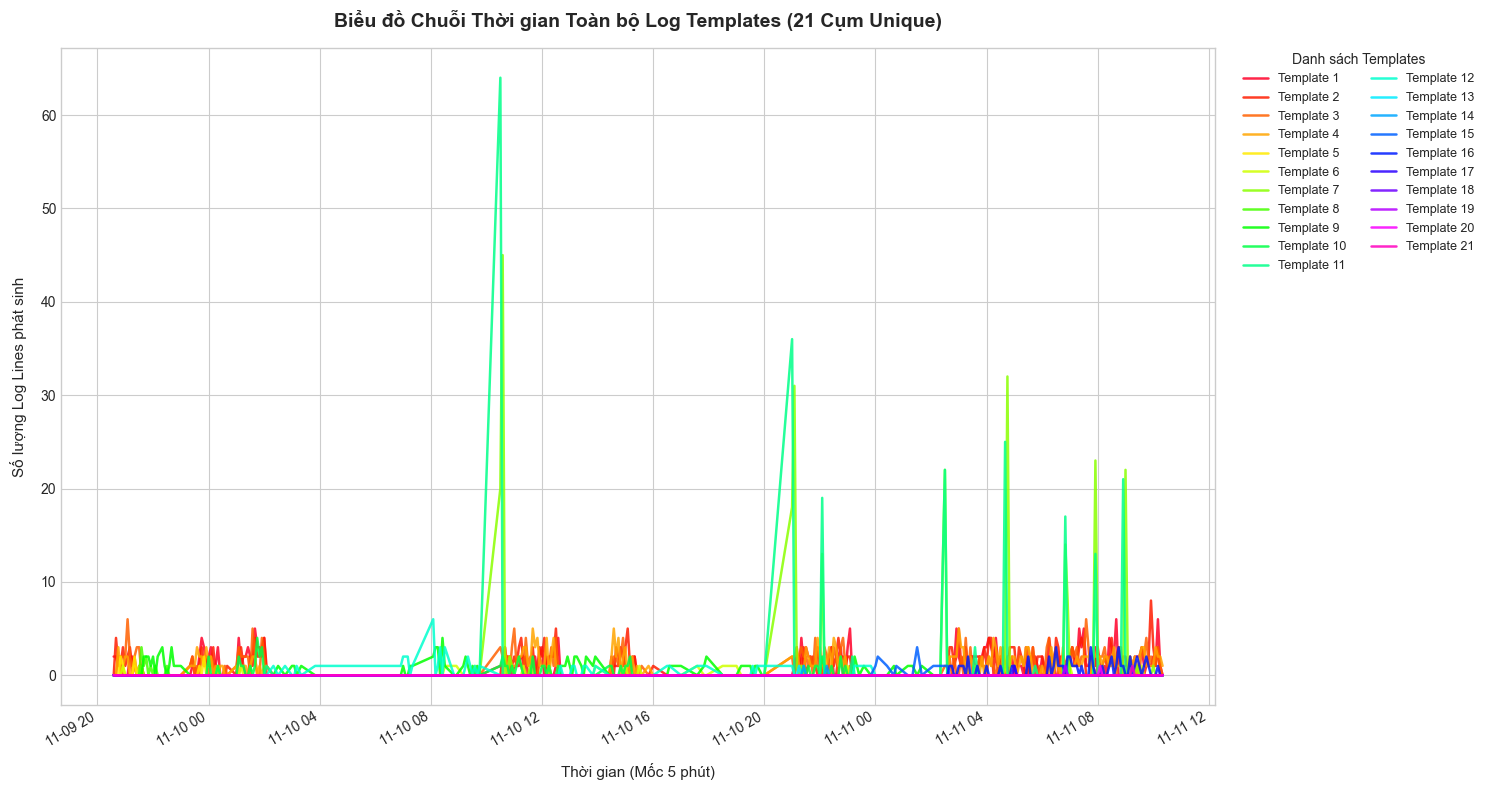

In [59]:

# Gọi hàm vẽ biểu đồ
plot_all_template_timeseries(ts)

In [62]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

X = ts.values
contamination_values = [0.01, 0.02, 0.05]
best_contamination = 0.02 \

iso_forest = IsolationForest(contamination=best_contamination, n_estimators=100, random_state=42)
predictions = iso_forest.fit_predict(X) # 1: Bình thường, -1: Bất thường

means = ts.mean()
stds = ts.std().replace(0, 1e-6) # Tránh lỗi chia cho 0 nếu template có số lượng cố định

spikes_by_time = defaultdict(list)
new_templates_by_time = defaultdict(list)

anomaly_count = 0
for idx, (timestamp, row) in enumerate(ts.iterrows()):
    is_if_anomaly = (predictions[idx] == -1)
    
    spikes_detected = []
    new_templates_detected = []
    
    for col in ts.columns:
        val = row[col]
        
        # Kiểm tra Template mới xuất hiện
        historical_sum = ts.loc[:timestamp, col].iloc[:-1].sum() if idx > 0 else 0
        if historical_sum == 0 and val > 0:
            new_templates_detected.append(f"T-{col:03d}(+{int(val)})")
            
        # Kiểm tra Spike bằng Z-score
        z_score = (val - means[col]) / stds[col]
        if z_score > 3:
            spikes_detected.append(f"T-{col:03d}(SL:{int(val)}/Z:{z_score:.1f})")
            
    # Lưu dữ liệu phục vụ biểu đồ (Kể cả khi không đủ điều kiện in ALERT)
    spikes_by_time[timestamp] = spikes_detected
    new_templates_by_time[timestamp] = new_templates_detected
            
    # Logic in kết quả ra stdout của bạn (Giữ nguyên)
    if is_if_anomaly or len(spikes_detected) > 0 or len(new_templates_detected) > 0:
        anomaly_count += 1
        print(f"ALERT tại [{timestamp}]")
        if is_if_anomaly:
            print("   ↳ Isolation Forest: Phát hiện bất thường tổng thể hệ thống (Multivariate)")
        if spikes_detected:
            print(f"   ↳ Thống kê 3σ phát hiện SPIKE: {', '.join(spikes_detected)}")
        if new_templates_detected:
            print(f"   ↳ Template MỚI XUẤT HIỆN: {', '.join(new_templates_detected)}")
        print("-" * 80)

print(f"\n=== Tổng kết: Tìm thấy {anomaly_count} khung giờ có dấu hiệu bất thường ===")

ALERT tại [2008-11-09 20:35:00]
   ↳ Template MỚI XUẤT HIỆN: T-001(+2)
--------------------------------------------------------------------------------
ALERT tại [2008-11-09 20:40:00]
   ↳ Template MỚI XUẤT HIỆN: T-002(+4)
--------------------------------------------------------------------------------
ALERT tại [2008-11-09 20:45:00]
   ↳ Template MỚI XUẤT HIỆN: T-003(+2), T-004(+3)
--------------------------------------------------------------------------------
ALERT tại [2008-11-09 20:50:00]
   ↳ Thống kê 3σ phát hiện SPIKE: T-005(SL:2/Z:9.3)
   ↳ Template MỚI XUẤT HIỆN: T-005(+2)
--------------------------------------------------------------------------------
ALERT tại [2008-11-09 20:55:00]
   ↳ Isolation Forest: Phát hiện bất thường tổng thể hệ thống (Multivariate)
   ↳ Thống kê 3σ phát hiện SPIKE: T-005(SL:1/Z:4.6), T-006(SL:1/Z:3.8)
   ↳ Template MỚI XUẤT HIỆN: T-006(+1)
--------------------------------------------------------------------------------
ALERT tại [2008-11-09 21:05:0

In [67]:
def plot_anomaly_highlights(ts_dataframe, predictions, spikes_by_time, new_templates_by_time):
    """
    Vẽ biểu đồ chuỗi thời gian của tất cả các template và highlight các điểm bất thường (Đã lọc nhiễu).
    """
    plt.figure(figsize=(16, 8))
    
    if 'seaborn-v0_8-whitegrid' in plt.style.available:
        plt.style.use('seaborn-v0_8-whitegrid')
        
    num_templates = len(ts_dataframe.columns)
    colors = plt.cm.get_cmap('tab20', num_templates) if num_templates <= 20 else plt.cm.get_cmap('gist_rainbow', num_templates)
    
    # 1. Vẽ đường xu hướng cho toàn bộ các Template
    for idx, template_id in enumerate(ts_dataframe.columns):
        plt.plot(
            ts_dataframe.index, 
            ts_dataframe[template_id], 
            label=f'Template {template_id}', 
            color=colors(idx),
            linewidth=1.5, 
            alpha=0.75
        )

    # 2. Quét qua từng mốc thời gian để highlight các điểm ALERT
    has_if_legend = False
    has_stat_legend = False
    
    # Đặt ngưỡng cứng để lọc nhiễu ở đáy đồ thị
    MIN_LOGS_TO_ALERT = 10 
    
    for idx, (timestamp, row) in enumerate(ts_dataframe.iterrows()):
        is_if_anomaly = (predictions[idx] == -1)
        
        # Lấy danh sách lỗi tại mốc này
        spikes = spikes_by_time[timestamp]
        news = new_templates_by_time[timestamp]
        
        max_val_at_ts = row.max()
        
        # A. Highlight vùng bất thường tổng thể bằng Isolation Forest
        if is_if_anomaly:
            label = 'Isolation Forest Anomaly' if not has_if_legend else ""
            plt.axvspan(timestamp, timestamp + pd.Timedelta(minutes=5), 
                        color='red', alpha=0.12, label=label)
            has_if_legend = True
            
        # B. Chấm điểm Marker (Đã gộp nhóm & Lọc nhiễu số lượng thấp)
        if (len(spikes) > 0 or len(news) > 0) and max_val_at_ts >= MIN_LOGS_TO_ALERT:
            # Ưu tiên màu đỏ đậm nếu có Template Mới, ngược lại màu cam nếu chỉ là Spike
            marker_color = 'darkred' if len(news) > 0 else 'orange'
            label = 'Statistical Anomaly (Spike/New)' if not has_stat_legend else ""
            
            # Chỉ vẽ duy nhất 1 marker cho mốc thời gian này dựa trên max_val
            plt.scatter(timestamp, max_val_at_ts + (max_val_at_ts * 0.05 + 2), 
                        color=marker_color, marker='v', s=100, zorder=5, label=label)
            has_stat_legend = True

    # 3. Định dạng biểu đồ
    plt.title(f"HỆ THỐNG GIÁM SÁT LOG - BIỂU ĐỒ PHÁT HIỆN BẤT THƯỜNG ({num_templates} TEMPLATES)", 
              fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Thời gian", fontsize=11, labelpad=10)
    plt.ylabel("Số lượng Log Lines phát sinh", fontsize=11, labelpad=10)
    
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.gcf().autofmt_xdate()
    
    num_legend_cols = max(1, num_templates // 20 + 1)
    if num_legend_cols > 4: num_legend_cols = 4
    
    plt.legend(
        title="Chú thích & Danh sách Templates", 
        loc='upper left', 
        bbox_to_anchor=(1.02, 1), 
        borderaxespad=0,
        ncol=num_legend_cols,
        fontsize=8.5
    )
    
    plt.tight_layout()
    plt.savefig('all_templates_anomaly_detection.png', dpi=200, bbox_inches='tight')
    plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_21864\3675225878.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', num_templates) if num_templates <= 20 else plt.cm.get_cmap('gist_rainbow', num_templates)


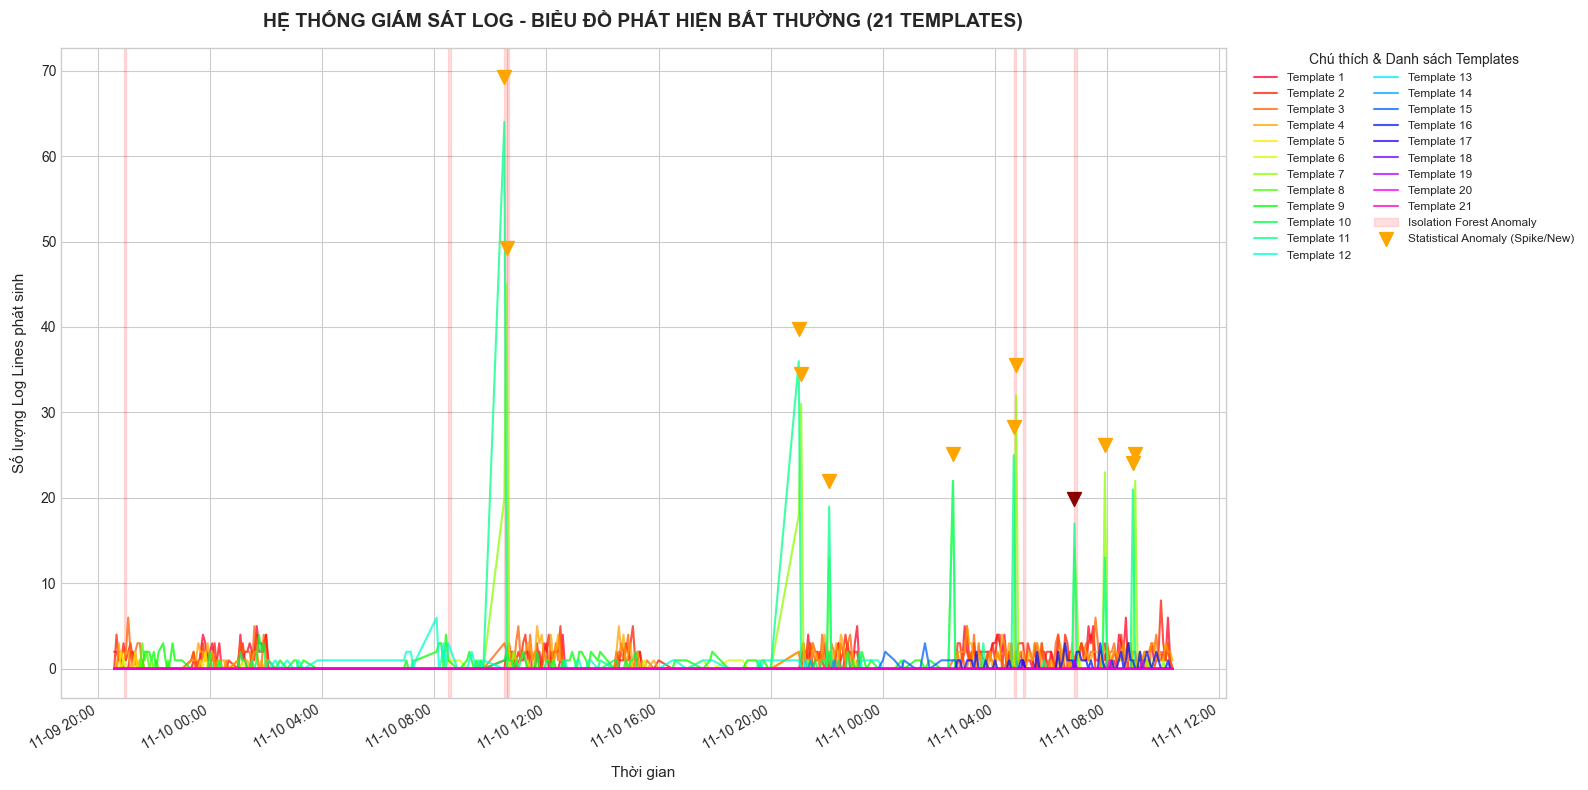

In [68]:

plot_anomaly_highlights(ts, predictions, spikes_by_time, new_templates_by_time)

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import numpy as np


means = ts.mean()
stds = ts.std().replace(0, 1e-6)
y_true = (ts > (means + 3 * stds)).any(axis=1).astype(int)

y_pred_if = (predictions == -1).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred_if).ravel()
precision = precision_score(y_true, y_pred_if, zero_division=0)
recall = recall_score(y_true, y_pred_if, zero_division=0)
f1 = f1_score(y_true, y_pred_if, zero_division=0)

try:
    auc = roc_auc_score(y_true, -iso_forest.score_samples(X))
    auc_str = f"{auc:.4f}"
except Exception:
    auc_str = "N/A"
print(f"\n[Thống Kê]: Tổng bất thường (3σ): {y_true.sum()} / {len(y_true)} khung giờ")
print("-" * 50)
print(f"| Ma Trận Nhầm Lẫn | Thực Tế: Lỗi (1) | Thực Tế: Thường (0) |")
print(f"|------------------|------------------|---------------------|")
print(f"| Máy Đoán: Lỗi (1)|  TP = {tp:<11d} |  FP = {fp:<15d} | -> Báo động giả: {fp}")
print(f"| Máy Đoán: Thường |  FN = {fn:<11d} |  TN = {tn:<15d} | -> Sót lỗi     : {fn}")
print("-" * 50)
print(f"Precision : {precision:.4%} ")
print(f"Recall    : {recall:.4%} ")
print(f"F1-Score  : {f1:.4%}")
print(f"AUC-ROC   : {auc_str}")
print("-" * 50)



[Thống Kê]: Tổng bất thường (3σ): 103 / 305 khung giờ
--------------------------------------------------
| Ma Trận Nhầm Lẫn | Thực Tế: Lỗi (1) | Thực Tế: Thường (0) |
|------------------|------------------|---------------------|
| Máy Đoán: Lỗi (1)|  TP = 7           |  FP = 0               | -> Báo động giả: 0
| Máy Đoán: Thường |  FN = 96          |  TN = 202             | -> Sót lỗi     : 96
--------------------------------------------------
Precision : 100.0000% 
Recall    : 6.7961% 
F1-Score  : 12.7273%
AUC-ROC   : 0.9526
--------------------------------------------------


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict

# 1. Trích xuất thuộc tính 'template' (dạng chuỗi) từ list dicts để đưa vào TF-IDF
pure_template_strings = [item['template'] for item in templates_data]

# 2. Vector hóa bằng TF-IDF (giữ lại token <*> để tăng độ chính xác)
vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b|<\*>')
tfidf_matrix = vectorizer.fit_transform(pure_template_strings)

# 2. Tính toán ma trận Cosine Similarity
sim_matrix = cosine_similarity(tfidf_matrix)

# 3. Chuyển đổi Similarity sang Distance Matrix (Khoảng cách = 1 - Tương đồng)
# Vì AgglomerativeClustering cần nhận vào khoảng cách (càng nhỏ càng gần)
distance_matrix = 1 - sim_matrix

# 4. Gom cụm bằng AgglomerativeClustering
# distance_threshold: Ngưỡng khoảng cách. 
# Ví dụ: 0.4 tương đương với việc các templates phải giống nhau ít nhất 60% (similarity >= 0.6) để vào cùng 1 nhóm.
cluster_model = AgglomerativeClustering(
    n_clusters=None, 
    metric='precomputed', 
    linkage='average', 
    distance_threshold=0.4 
)
cluster_labels = cluster_model.fit_predict(distance_matrix)

# 5. Tổ chức và hiển thị kết quả gom cụm
clusters = defaultdict(list)
for idx, label in enumerate(cluster_labels):
    clusters[label].append(templates_data[idx])

print("=== KẾT QUẢ GOM CỤM LOG TEMPLATES ===")
for cluster_id, items in clusters.items():
    print(f"\n[Cluster {cluster_id}] ({len(items)} templates):")
    for item in items:
        print(f" - {item}")


=== KẾT QUẢ GOM CỤM LOG TEMPLATES ===

[Cluster 4] (2 templates):
 - {'template_id': 5, 'count': 628, 'template': '<*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>'}
 - {'template_id': 13, 'count': 448, 'template': '<*> <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.delete: <*> is added to invalidSet of <*>'}

[Cluster 9] (1 templates):
 - {'template_id': 4, 'count': 622, 'template': '<*> <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating'}

[Cluster 0] (7 templates):
 - {'template_id': 6, 'count': 584, 'template': '<*> <*> <*> INFO dfs.DataNode$PacketResponder: Received block <*> of size <*> from <*>'}
 - {'template_id': 7, 'count': 584, 'template': '<*> <*> <*> INFO dfs.DataNode$DataXceiver: Receiving block <*> src: <*> dest: <*>'}
 - {'template_id': 10, 'count': 526, 'template': '<*> <*> <*> INFO dfs.FSDataset: Deleting block <*> file <*>'}
 - {'template_id': 8, 'count': 230, '

In [41]:
strange_log = "2026-06-02 12:00:00 CRITICAL security_audit: Unauthorized root access attempt detected from IP 192.168.1.99 - Target: /etc/shadow [STATUS=FAILED]"
print(f"--- Injecting strange log: ---\n{strange_log}\n")

--- Injecting strange log: ---
2026-06-02 12:00:00 CRITICAL security_audit: Unauthorized root access attempt detected from IP 192.168.1.99 - Target: /etc/shadow [STATUS=FAILED]



In [42]:
miner.add_log_message(strange_log)
templates_data = []
for cluster in miner.drain.clusters:
    templates_data.append({
        'template_id': cluster.cluster_id,
        'count': cluster.size,
        'template': cluster.get_template()
    })
latest_template_id = miner.drain.id_to_cluster[list(miner.drain.id_to_cluster.keys())[-1]].cluster_id

In [ ]:

pure_template_strings = [item['template'] for item in templates_data]

# Vector hóa với token_pattern giữ nguyên <*>
vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b|<\*>')
tfidf_matrix = vectorizer.fit_transform(pure_template_strings)

# Tính Similarity Matrix
sim_matrix = cosine_similarity(tfidf_matrix)

# Tìm ra vị trí index của Template lạ trong danh sách templates_data
strange_idx = next(i for i, item in enumerate(templates_data) if item['template_id'] == latest_template_id)

# Lấy ra mảng độ tương đồng của Template lạ này so với TẤT CẢ các templates còn lại
strange_similarities = sim_matrix[strange_idx]

# Tính độ tương đồng cao nhất của nó với một template bất kỳ trong hệ thống (loại trừ chính nó)
# Nếu Max Similarity thấp -> Chứng tỏ nó là một cấu trúc log "Độc bản" (Anomaly)
similarities_excluding_self = np.delete(strange_similarities, strange_idx)
max_similarity_score = np.max(similarities_excluding_self)


distance_matrix = np.clip(1 - sim_matrix, 0, 1)
cluster_model = AgglomerativeClustering(
    n_clusters=None, 
    metric='precomputed', 
    linkage='average', 
    distance_threshold=0.4 # Ngưỡng tương đồng tối thiểu 60%
)
cluster_labels = cluster_model.fit_predict(distance_matrix)

super_clusters = defaultdict(list)
for idx, label in enumerate(cluster_labels):
    super_clusters[label].append(templates_data[idx])


print(f"-> Drain3 đã tạo Template mới cho log lạ: ID [{latest_template_id}]")
print(f"-> Cấu trúc trích xuất: \"{templates_data[strange_idx]['template']}\"")
print(f"-> Độ tương đồng cao nhất với các template cũ: {max_similarity_score:.4f}")

if max_similarity_score < 0.25:
    print("\n[ALERT] PHÁT HIỆN LOG ANOMALY: Cấu trúc log này hoàn toàn mới và khác biệt so với tri thức cũ!")
else:
    print("\n[INFO] Cấu trúc log mới có nét tương đồng với một số log cũ.")
for cluster_id, items in super_clusters.items():
    contains_strange = any(item['template_id'] == latest_template_id for item in items)
    if contains_strange:
        print(f"\n[SUPER CLUSTER {cluster_id}] (Chứa log lạ vừa inject):")
        for sub_item in items:
            marker = "==> [NEW ANOMALY]" if sub_item['template_id'] == latest_template_id else "    "
            print(f"  {marker} [Drain-ID {sub_item['template_id']}] -> {sub_item['template']}")

-> Drain3 đã tạo Template mới cho log lạ: ID [21]
-> Cấu trúc trích xuất: "2026-06-02 12:00:00 CRITICAL security_audit: Unauthorized root access attempt detected from IP 192.168.1.99 - Target: /etc/shadow [STATUS=FAILED]"
-> Độ tương đồng cao nhất với các template cũ: 0.0550

[ALERT] PHÁT HIỆN LOG ANOMALY: Cấu trúc log này hoàn toàn mới và khác biệt so với tri thức cũ!

--- Vị trí của log lạ trong các Super Clusters ---

★ [SUPER CLUSTER 1] (Chứa log lạ vừa inject):
  ==> [NEW ANOMALY] [Drain-ID 21] -> 2026-06-02 12:00:00 CRITICAL security_audit: Unauthorized root access attempt detected from IP 192.168.1.99 - Target: /etc/shadow [STATUS=FAILED]
